# Maximum Likelihood from Particle Decays

*Goal:* In this notebook, you'll learn how to go from probability distributions you already know to the idea of **likelihood** and **maximum likelihood estimation (MLE)**.  

We'll use a classic example from high-energy particle physics: measuring the **lifetime** of an unstable particle from its decay times.


In [2]:
# setup
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import interact, FloatSlider, IntSlider, VBox, HBox, Button, fixed
from IPython.display import display

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["font.size"] = 12

## Unstable Particles and Decay Times

In many high-energy physics experiments, unstable particles are produced in a collision and then decay after some random time.

- Let $t$ be the **decay time** of a particle.
- Theory predicts that for many unstable particles, the probability density of $t$ is **exponential**:

$$
f(t \mid \tau) = 
\begin{cases}
\frac{1}{\tau}\,\exp(-t / \tau) & t \ge 0 \\
0 & t < 0
\end{cases}
$$

where:
- $t$ is the decay time you measure,
- $\tau$ is the **lifetime** (mean decay time) predicted by the model.

Today, we pretend we don't know the true lifetime $\tau$.  
Instead, we will use **data** (a sample of decay times) to *estimate* $\tau$.


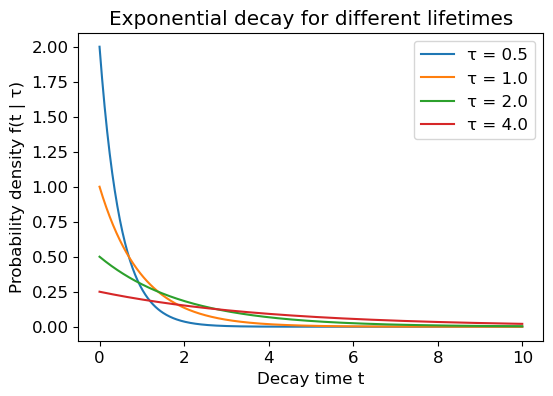

In [3]:
def exponential_pdf(t, tau):
    return (t >= 0) * (1.0 / tau) * np.exp(-t / tau)

def plot_exponential_family():
    t = np.linspace(0, 10, 500)
    taus = [0.5, 1.0, 2.0, 4.0]

    for tau in taus:
        plt.plot(t, exponential_pdf(t, tau), label=f"τ = {tau:.1f}")
    plt.xlabel("Decay time t")
    plt.ylabel("Probability density f(t | τ)")
    plt.title("Exponential decay for different lifetimes")
    plt.legend()
    plt.show()

plot_exponential_family()


## 2. A single decay time

Imagine our detector records **one** decay time:

$$
t_{\text{obs}} = 1.8\,\text{ns}
$$

For a given model (value of $\tau$), the exponential distribution tells us how *typical* this value is.

We will:

1. Fix $t_{\text{obs}}$.
2. Slide $\tau$ around.
3. See how the *height* of the exponential at $t_{\text{obs}}$,
   $f(t_{\text{obs}} \mid \tau)$, changes.


In [4]:
def single_event_plot(t_obs=1.8, tau=1.0):
    t = np.linspace(0, 10, 500)
    pdf = exponential_pdf(t, tau)
    like = exponential_pdf(np.array([t_obs]), tau)[0]

    plt.plot(t, pdf)
    plt.axvline(t_obs, linestyle="--")
    plt.scatter([t_obs], [like])
    plt.xlabel("Decay time t")
    plt.ylabel("f(t | τ)")
    plt.title(f"Single decay at t_obs = {t_obs:.2f}, τ = {tau:.2f}")
    plt.show()

    print(f"Model lifetime τ = {tau:.2f}")
    print(f"Probability density at t_obs: f(t_obs | τ) = {exponential_pdf(np.array([t_obs]), tau)[0]:.4f}")

interact(
    single_event_plot,
    t_obs=FloatSlider(value=1.8, min=0.1, max=5.0, step=0.1, description="t_obs"),
    tau=FloatSlider(value=1.0, min=0.2, max=5.0, step=0.1, description="τ (model)")
);


interactive(children=(FloatSlider(value=1.8, description='t_obs', max=5.0, min=0.1), FloatSlider(value=1.0, de…

**Exercise**

1. Move the slider for $\tau$.  
   For which values of $\tau$ does the peak of the distribution sit closer to $t_{\text{obs}}$?
2. For which values of $\tau$ is $f(t_{\text{obs}} \mid \tau)$ highest?
3. Which model $\tau$ would you *prefer* given only this one measurement?

You have just used the idea behind **likelihood** without naming it yet.


## Likelihood for a single decay

For a fixed observed decay time $t_{\text{obs}}$, the exponential density

$
f(t_{\text{obs}} \mid \tau)
$

is a function of $\tau$.  
We give this function a special name: the **likelihood** of $\tau$ given the data,

$$
L(\tau \mid t_{\text{obs}}) = f(t_{\text{obs}} \mid \tau).
$$

- As a *function of $t$* with fixed $\tau$: it's a **probability density**.
- As a *function of $\tau$* with fixed $t_{\text{obs}}$: it's a **likelihood**.

Mathematically the formula is the same, but the interpretation is different.


In [5]:
def likelihood_single(t_obs=1.8):
    taus = np.linspace(0.2, 5.0, 400)
    L = exponential_pdf(np.full_like(taus, t_obs), taus)

    plt.plot(taus, L)
    plt.xlabel("τ (model lifetime)")
    plt.ylabel("L(τ)")
    plt.title(f"Likelihood for a single decay at t_obs = {t_obs:.2f}")
    plt.show()

interact(
    likelihood_single,
    t_obs=FloatSlider(value=1.8, min=0.1, max=5.0, step=0.1, description="t_obs")
);


interactive(children=(FloatSlider(value=1.8, description='t_obs', max=5.0, min=0.1), Output()), _dom_classes=(…

**Exercise**

1. For a small $t_{\text{obs}}$, what kind of lifetimes (small vs large) are more likely?
2. For a large $t_{\text{obs}}$, what kind of lifetimes are more likely?

This connects the *physics story* (a short-lived particle decays quickly) with the *shape of the likelihood*.


## Many decays: joint probability

In a real experiment we don't stop at one decay. We produce many particles:

$$
t_1, t_2, \dots, t_n
$$

If we assume each decay time is independent and follows the same exponential distribution with lifetime $\tau$, then the **joint probability density** of all of them is

$$
f(t_1, \dots, t_n \mid \tau)
= \prod_{i=1}^n f(t_i \mid \tau).
$$

If we now fix the observed data $t_1, \dots, t_n$ and view this as a function of $\tau$, we get the **likelihood for multiple data points**:

$$
L(\tau \mid t_1, \dots, t_n)
= \prod_{i=1}^n f(t_i \mid \tau).
$$


In [6]:
def simulate_decays(true_tau, n):
    return np.random.exponential(scale=true_tau, size=n)

def log_likelihood_exponential(t, tau):
    # Sum of logs to avoid underflow
    if tau <= 0:
        return -np.inf
    return -len(t) * np.log(tau) - np.sum(t) / tau

def multi_decay_demo(true_tau=1.5, n=5):
    np.random.seed(0)  # for reproducibility in the demo
    t = simulate_decays(true_tau, n)

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    # Left: data histogram
    bins = np.linspace(0, max(5, t.max() * 1.2), 15)
    ax[0].hist(t, bins=bins, density=True, alpha=0.6, label="data")

    tt = np.linspace(0, bins[-1], 300)
    ax[0].plot(tt, exponential_pdf(tt, true_tau), label=f"true τ = {true_tau:.2f}")
    ax[0].set_xlabel("Decay time t")
    ax[0].set_ylabel("Density")
    ax[0].legend()
    ax[0].set_title(f"{n} decay times")

    # Right: log-likelihood as a function of τ
    taus = np.linspace(0.2, 5.0, 400)
    ll = np.array([log_likelihood_exponential(t, tau) for tau in taus])

    ax[1].plot(taus, ll)
    ax[1].set_xlabel("τ")
    ax[1].set_ylabel("log L(τ)")
    ax[1].set_title("Log-likelihood curve")

    plt.tight_layout()
    plt.show()

interact(
    multi_decay_demo,
    true_tau=FloatSlider(value=1.2, min=0.1, max=2.0, step=0.1, description="true τ"),
    n=IntSlider(value=5, min=1, max=2000, step=1, description="n events")
);


interactive(children=(FloatSlider(value=1.2, description='true τ', max=2.0, min=0.1), IntSlider(value=5, descr…

**Exercise**

1. Increase the number of events $n$. What happens to the shape of the log-likelihood curve?
2. How does the position of the peak compare to the true lifetime $\tau_{\text{true}}$?


## Maximum likelihood estimation (MLE)

The **maximum likelihood estimate (MLE)** of $\tau$ is defined as

$$
\hat{\tau}_{\text{MLE}} = \arg \max_{\tau} L(\tau \mid t_1, \dots, t_n).
$$

Because products of many small numbers can underflow, we usually work with the **log-likelihood**:

$$
\ell(\tau) = \log L(\tau) = \sum_{i=1}^n \log f(t_i \mid \tau).
$$

Maximizing $\ell(\tau)$ is equivalent to maximizing $L(\tau)$, but numerically more stable.


In [7]:
def mle_demo(true_tau=1.5, n=30):
    t = simulate_decays(true_tau, n)

    taus = np.linspace(0.2, 5.0, 400)
    ll = np.array([log_likelihood_exponential(t, tau) for tau in taus])

    tau_hat = taus[np.argmax(ll)]

    fig, ax = plt.subplots()
    ax.plot(taus, ll, label="log-likelihood")
    ax.axvline(true_tau, linestyle="--", label=f"true τ = {true_tau:.2f}")
    ax.axvline(tau_hat, linestyle="-.", label=f"MLE τ̂ = {tau_hat:.2f}")
    ax.set_xlabel("τ")
    ax.set_ylabel("log L(τ | data)")
    ax.legend()
    plt.show()

    print(f"True lifetime τ_true = {true_tau:.3f}")
    print(f"MLE τ_hat = {tau_hat:.3f}")
    print(f"Sample mean of t_i = {np.mean(t):.3f} (we'll come back to this!)")

interact(
    mle_demo,
    true_tau=FloatSlider(value=1.5, min=0.1, max=3.0, step=0.1, description="true τ"),
    n=IntSlider(value=30, min=5, max=1000, step=5, description="n events")
);


interactive(children=(FloatSlider(value=1.5, description='true τ', max=3.0, min=0.1), IntSlider(value=30, desc…

**Exercise**

1. For small $n$, does $\hat{\tau}$ jump around more or less than for large $n$?
2. Compare the MLE $\hat{\tau}$ to the simple sample mean $\bar{t}$. What do you notice?


## Optional: solving for the MLE by calculus

For the exponential model, the log-likelihood is

$$
\ell(\tau)
= -n \log \tau - \frac{1}{\tau} \sum_{i=1}^n t_i.
$$

If we differentiate with respect to $\tau$ and set the result equal to zero, we find

$$
\hat{\tau}_{\text{MLE}} = \frac{1}{n} \sum_{i=1}^n t_i,
$$

so the MLE of the lifetime is simply the **sample mean** of the decay times.

This is not true for all models, but it is a nice example of how maximum likelihood
connects to familiar summary statistics.


## Summary and outlook

In this notebook you:

- Started from a **physics model** (unstable particle with lifetime $\tau$).
- Used the corresponding **probability distribution** (exponential) to compute
  the probability density of observed decay times.
- Flipped the perspective to view this as a **likelihood function** of $\tau$.
- Combined multiple independent decay times into a **joint likelihood**.
- Found the **maximum likelihood estimate** of $\tau$ by maximizing the log-likelihood.

This pattern is very general:

1. Write down a probability model $p(\text{data} \mid \theta)$.
2. For observed data, regard this as a likelihood $L(\theta)$.
3. Choose the parameter $\hat{\theta}$ that maximizes $L(\theta)$.

In high-energy particle physics, the same idea is used to estimate:

- **Cross sections** from counting experiments with Poisson models.
- **Particle masses** from invariant mass spectra modeled as
  “signal peak + background”.
- **Efficiencies** and **background rates** in complex detector simulations.

# In-class Plots: pion-proton decay

The code below is primarily to recreate plots shown during class, not an exercise. For the accompanying exercise, see [the lecture notes](https://philuttley.github.io/stats-methods-25/05-mle_model_fitting/index.html).

In [8]:
pwd = "/Users/danielahuppenkothen/work/repositories/stats-methods-25/data/"

In [9]:
pion = np.genfromtxt(pwd+'pedroni.txt', dtype='float', usecols=(0,1,2), names=True)


In [10]:
pion_clean = np.sort(pion[pion['energy'] <= 313], axis=0)
print(pion_clean.dtype.names) # Check field names for columns of structured array


('energy', 'xsect', 'error')


Text(0, 0.5, 'Cross section $\\sigma(E)$')

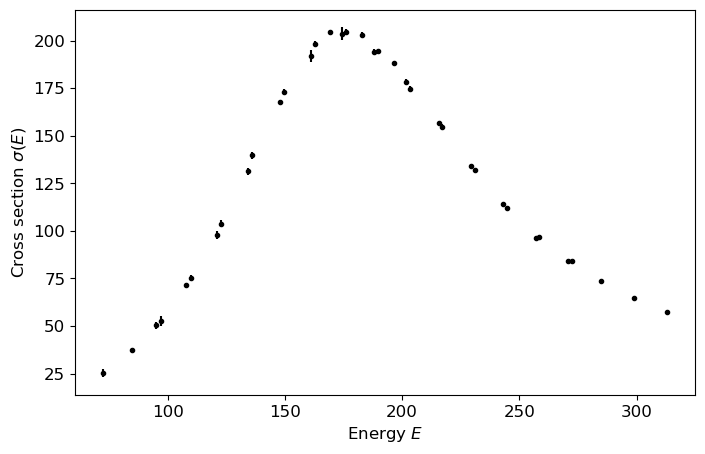

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))

ax.errorbar(pion_clean["energy"], pion_clean["xsect"], yerr=pion_clean["error"], 
            fmt="o", color="black", markersize=3)
ax.set_xlabel(r"Energy $E$")
ax.set_ylabel(r"Cross section $\sigma(E)$")

In [12]:
def breitwigner(e_val,params):
    '''Function for non-relativistic Breit-Wigner formula, returns pi-p interaction cross-section
    for input energy and parameters resonant width, resonant energy and normalisation.'''
    v = params.valuesdict()
    gam=v['gam0']*np.sqrt(e_val/130.)
    return v['N']*(gam**2/4)/((e_val-v['E0'])**2+gam**2/4)

def gauss_loglike(pion_clean, model):
    npoints = len(pion_clean["xsect"])
    t1 = -npoints/2*np.log(2*np.pi)
    t2 = -npoints/2*np.log(pion_clean["error"]**2.)
    t3 = -1./(2*pion_clean["error"]**2.) * np.sum((pion_clean["xsect"] - model)**2.)

    return t1 + t2 + t3
    

In [13]:
import lmfit

In [16]:
import lmfit
from lmfit import Minimizer, Parameters, report_fit

params = Parameters()  # Assigns a variable name to an empty Parameters object
params.add_many(('gam0',30),('E0',130),('N',150))  # Adds multiple parameters, specifying the name and starting value

In [19]:
def mle_demo(gam=1.5, e0=1.0, n=2.0):
    print(params)
    model = breitwigner(pion_clean["energy"], params)
    loglike = gauss_loglike(pion_clean, model)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))
    ax1.errorbar(pion_clean["energy"], pion_clean["xsect"], yerr=pion_clean["error"], 
            fmt="o", color="black", markersize=3)    
    ax1.plot(pion_clean["energy"], model)
    ax1.set_xlabel("τ")
    ax1.set_ylabel("log L(τ)")
    ax1.legend()
    plt.show()

    #print(f"True lifetime τ_true = {true_tau:.3f}")
    print(f"MLE τ_hat = {tau_hat:.3f}")
    print(f"Sample mean of t_i = {np.mean(t):.3f} (we'll come back to this!)")

interact(
    mle_demo,
    true_tau=FloatSlider(value=1.5, min=0.1, max=3.0, step=0.1, description="true τ"),
    n=IntSlider(value=30, min=5, max=1000, step=5, description="n events")
);


interactive(children=(FloatSlider(value=1.5, description='gam', max=4.5, min=-1.5), FloatSlider(value=1.0, des…